# Systematic Trading Strategies | Coursework (Group Project)
## Part 1: Feature Engineering & Part 2: Trading Strategy Pipeline

> This notebook is part of a group coursework project.


## 0  Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.stats import rankdata
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 10})

ASSET_CLASSES = {
    "metals": ["gc1s", "si1s", "hg1s", "pl1s"],
    "equity": ["es1s", "nq1s", "fesx1s"],
    "energy": ["cl1s", "ho1s", "rb1s", "ng1s"],
}
ALL_TICKERS = [t for v in ASSET_CLASSES.values() for t in v]

TRAIN_START, TRAIN_END = "2020-01-01", "2021-12-31"
OOS_START,  OOS_END   = "2022-01-01", "2022-06-30"
SEED = 42

Path("outputs").mkdir(exist_ok=True)

# Feature catalogue
FEAT_DOC = {}
def doc(name, family, description):
    FEAT_DOC[name] = (family, description)


## 1  Data Loading

In [2]:
ohlcv   = pd.read_csv("ohlcv_data.csv", parse_dates=["date"])
signals = pd.read_csv("primary_signals.csv", parse_dates=["date"])

ohlcv["instrument"] = ohlcv["instrument"].str.lower().str.strip()
ohlcv = ohlcv.sort_values(["instrument", "date"]).reset_index(drop=True)
ohlcv.loc[ohlcv["volume"] <= 0, "volume"] = np.nan  # zero-vol days → NaN

signals_long = (signals
    .melt(id_vars="date", var_name="instrument", value_name="signal")
    .assign(instrument=lambda d: d["instrument"].str.lower().str.strip()))

print(f"OHLCV: {len(ohlcv):,} rows  |  Signal rows: {len(signals_long):,}")
print(f"Instruments: {sorted(ohlcv.instrument.unique())}")
print(f"\nDate range: {ohlcv.date.min().date()} → {ohlcv.date.max().date()}")
print(f"Signal window: {signals.date.min().date()} → {signals.date.max().date()}")


OHLCV: 83,547 rows  |  Signal rows: 7,095
Instruments: ['cl1s', 'es1s', 'fesx1s', 'gc1s', 'hg1s', 'ho1s', 'ng1s', 'nq1s', 'pl1s', 'rb1s', 'si1s']

Date range: 1990-01-02 → 2022-06-30
Signal window: 2020-01-03 → 2022-06-30


## 2  Exploratory Data Analysis

Before engineering features we inspect signal activity and price dynamics across
instruments. This informs barrier parameter choices later.


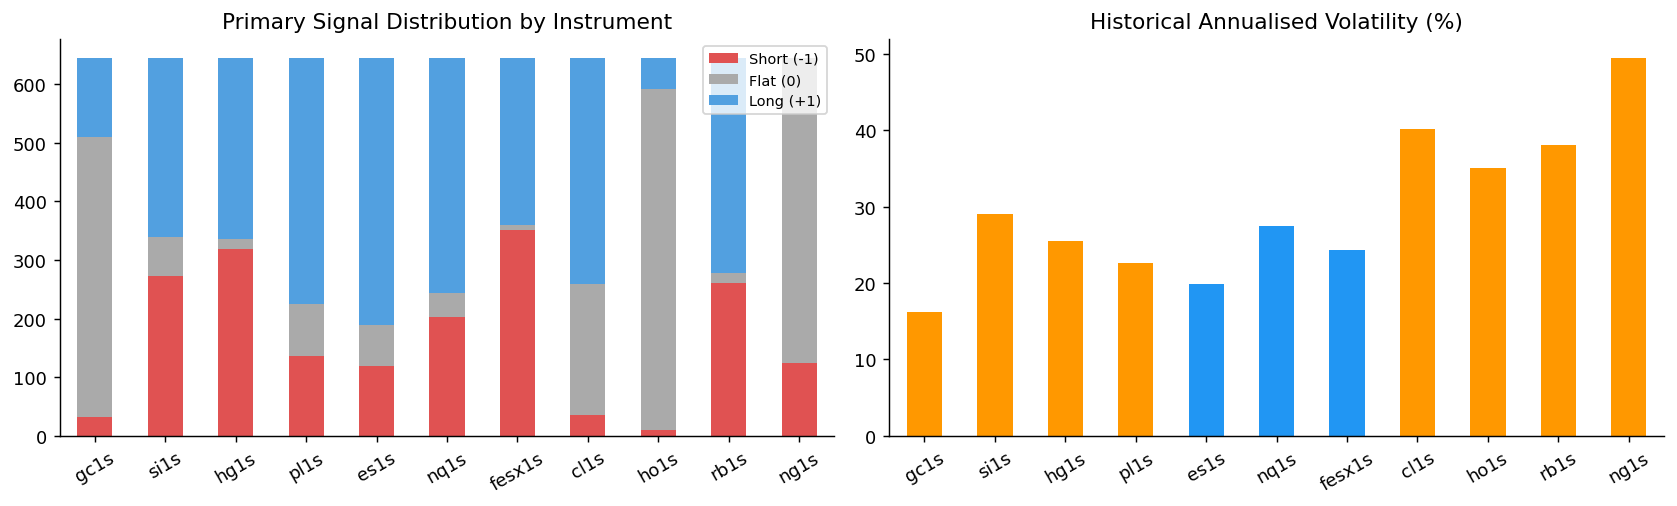


Signal balance (% long | % short):
  gc1s    : long=81.0%  short=19.0%  active=26.0%
  si1s    : long=52.9%  short=47.1%  active=89.6%
  hg1s    : long=49.2%  short=50.8%  active=97.4%
  pl1s    : long=75.6%  short=24.4%  active=86.4%
  es1s    : long=79.3%  short=20.7%  active=89.1%
  nq1s    : long=66.6%  short=33.4%  active=93.6%
  fesx1s  : long=44.9%  short=55.1%  active=98.8%
  cl1s    : long=91.5%  short= 8.5%  active=65.4%
  ho1s    : long=84.1%  short=15.9%  active= 9.8%
  rb1s    : long=58.4%  short=41.6%  active=97.4%
  ng1s    : long= 0.0%  short=100.0%  active=19.2%


In [3]:
# Signal distribution per instrument
sig_counts = (signals_long
    .groupby(["instrument", "signal"])
    .size().unstack(fill_value=0)
    .reindex(ALL_TICKERS, fill_value=0))
sig_counts.columns = ["Short (-1)", "Flat (0)", "Long (+1)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sig_counts.plot.bar(stacked=True, ax=axes[0],
    color=["#e05252", "#aaaaaa", "#52a0e0"], edgecolor="none")
axes[0].set_title("Primary Signal Distribution by Instrument")
axes[0].set_xlabel(""); axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].legend(loc="upper right", fontsize=8)

# Annualised vol by instrument (full history)
vols = (ohlcv.groupby("instrument")
    .apply(lambda d: np.log(d.close / d.close.shift(1)).std() * np.sqrt(252))
    .reindex(ALL_TICKERS) * 100)
vols.plot.bar(ax=axes[1], color=["#2196F3" if t in ASSET_CLASSES["equity"]
    else "#FF9800" for t in vols.index], edgecolor="none")
axes[1].set_title("Historical Annualised Volatility (%)")
axes[1].set_xlabel(""); axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig("outputs/eda_overview.png", bbox_inches="tight")
plt.show()

print("\nSignal balance (% long | % short):")
for t in ALL_TICKERS:
    s = signals_long[signals_long.instrument == t]["signal"]
    nz = s[s != 0]
    if len(nz) == 0: continue
    print(f"  {t:8s}: long={( nz>0).mean()*100:4.1f}%  short={(nz<0).mean()*100:4.1f}%  active={(s!=0).mean()*100:4.1f}%")


## 3  Feature Engineering

Features are computed **per instrument** using only past information (rolling
windows, closed on the left). The `doc()` call records each feature in
`FEAT_DOC` for the auto-generated feature dictionary.

### Design principles
* **No look-ahead** – all rolling statistics use `[t-window, t]`
* **Economic rationale first** – every feature answers a specific question about
  whether the primary signal will succeed
* **Signal interactions** – the same volatility level means something different
  depending on whether the primary signal is long or short


In [4]:
# 
def sma(s, w): return s.rolling(w, min_periods=max(2, w//2)).mean()
def ewm(s, sp): return s.ewm(span=sp, min_periods=max(2, sp//2), adjust=False).mean()

def compute_features(df):
    """All feature families for a single instrument."""
    df = df.sort_values("date").copy()
    c, h, l, o, v, oi = df.close, df.high, df.low, df.open, df.volume, df.open_interest

    # Family 1: Returns 
    r = np.log(c / c.shift(1))
    df["ret_1d"]  = r;                               doc("ret_1d",  "returns", "1d log return")
    df["ret_5d"]  = np.log(c / c.shift(5));          doc("ret_5d",  "returns", "5d log return; short-term momentum")
    df["ret_20d"] = np.log(c / c.shift(20));         doc("ret_20d", "returns", "20d log return; medium-term momentum")
    df["ret_60d"] = np.log(c / c.shift(60));         doc("ret_60d", "returns", "60d log return; trend strength")
    df["ret_overnight"] = np.log(o / c.shift(1));    doc("ret_overnight", "returns", "Overnight gap; regime-shift proxy")
    df["ret_intraday"]  = np.log(c / o);             doc("ret_intraday",  "returns", "Intraday return; intraday conviction")
    for w in [5, 10, 21, 63]:
        n = f"realvol_{w}d"
        df[n] = r.rolling(w).std() * np.sqrt(252);  doc(n, "returns", f"Realised vol {w}d (ann); risk level of the bet")
    df["ret_skew_21"] = r.rolling(21).skew();        doc("ret_skew_21", "returns", "21d return skew; crash vs melt-up")
    df["ret_kurt_21"] = r.rolling(21).kurt();        doc("ret_kurt_21", "returns", "21d return kurtosis; fat-tail risk")
    df["ret5_zscore"] = (df.ret_5d - df.ret_5d.rolling(252).mean()) / (df.ret_5d.rolling(252).std() + 1e-9)
    doc("ret5_zscore", "returns", "5d return z-score vs 1y; overextension / stretch metric")

    # Family 2: Trend & Momentum 
    ema20 = c.ewm(span=20, adjust=False).mean()
    df["ema_slope"] = ema20 - ema20.shift(5);        doc("ema_slope", "trend", "EMA(20) slope over 5d; trend acceleration")
    df["ema_accel"] = df.ema_slope - df.ema_slope.shift(5)
    doc("ema_accel", "trend", "Second derivative of EMA(20); momentum deceleration signal")
    for f, s in [(5, 20), (10, 50), (20, 100)]:
        n = f"ema_xover_{f}_{s}"
        df[n] = (ewm(c, f) - ewm(c, s)) / (ewm(c, s) + 1e-9)
        doc(n, "trend", f"EMA({f})–EMA({s}) normalised; trend position")
    macd_line = ewm(c, 12) - ewm(c, 26)
    df["macd_hist"] = (macd_line - ewm(macd_line, 9)) / (c + 1e-9)
    doc("macd_hist", "trend", "MACD histogram / price; momentum inflection point")
    d_close = c.diff()
    rs = ewm(d_close.clip(lower=0), 14) / (ewm((-d_close).clip(lower=0), 14) + 1e-9)
    df["rsi_14"] = (100 - 100 / (1 + rs) - 50) / 50   # centred to [-1,+1]
    doc("rsi_14", "trend", "RSI(14) centred; overbought/oversold on [-1,1]")
    df["dist_52w_high"] = c / c.rolling(252).max() - 1
    doc("dist_52w_high", "trend", "Distance below 52w high; drawdown from peak")
    df["dist_52w_low"]  = c / c.rolling(252).min() - 1
    doc("dist_52w_low",  "trend", "Distance above 52w low; recovery extent")

    # Family 3: Volatility & Range 
    tr = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
    for w in [5, 14, 21]:
        n = f"atr_{w}_norm"
        df[n] = tr.rolling(w).mean() / (c + 1e-9)
        doc(n, "volatility", f"ATR({w}) as % of price; volatility level")
    # ATR percentile over 1 year – normalises across instruments
    df["atr14_pct252"] = (df.atr_14_norm if "atr_14_norm" in df.columns
                          else tr.rolling(14).mean() / (c + 1e-9)).rolling(252).apply(
                              lambda x: rankdata(x)[-1] / len(x), raw=False)
    doc("atr14_pct252", "volatility", "ATR(14) percentile vs 1y; relative volatility regime (cross-instrument comparable)")
    for w in [10, 20]:
        mid, sd = sma(c, w), c.rolling(w, min_periods=2).std()
        df[f"bb_pctb_{w}"] = (c - (mid - 2*sd)) / (4*sd + 1e-9)
        doc(f"bb_pctb_{w}", "volatility", f"Bollinger %B({w}); position in ±2σ band")
        df[f"bb_width_{w}"] = 4*sd / (mid + 1e-9)
        doc(f"bb_width_{w}", "volatility", f"Bollinger bandwidth({w}); volatility expansion vs squeeze")
    hl = np.log(h / (l + 1e-9))
    df["parkinson_21"] = np.sqrt((hl**2).rolling(21).mean() / (4*np.log(2))) * np.sqrt(252)
    doc("parkinson_21", "volatility", "Parkinson high-low vol (21d ann); more efficient than close-to-close [Parkinson 1980]")
    gk = 0.5*hl**2 - (2*np.log(2) - 1)*np.log(c/(o+1e-9))**2
    df["gk_21"] = np.sqrt(gk.rolling(21).mean().clip(lower=0) * 252)
    doc("gk_21", "volatility", "Garman-Klass OHLC vol (21d ann); uses open-to-close alongside high-low")
    df["vol_ratio_5_21"] = r.rolling(5).std() / (r.rolling(21).std() + 1e-9)
    doc("vol_ratio_5_21", "volatility", "Short/long vol ratio; vol spike detector (>1 = unusually active day)")
    df["vol_of_vol"] = (r.rolling(21).std()*np.sqrt(252)).rolling(63).std()
    doc("vol_of_vol", "volatility", "Vol-of-vol over 63d; regime instability — high VoV → signal unreliable")

    # Family 4: Microstructure 
    for w in [5, 10, 20]:
        n = f"vol_ratio_{w}d"
        df[n] = v / (v.rolling(w).mean() + 1e-9)
        doc(n, "microstructure", f"Volume vs {w}d average; participation / conviction signal")
    obv = (np.sign(c.diff()).fillna(0) * v).cumsum()
    df["obv_norm"] = obv / (obv.rolling(252).std() + 1e-9)
    doc("obv_norm", "microstructure", "On-Balance-Volume (normalised); cumulative buy/sell pressure")
    vwap5 = (c * v).rolling(5).sum() / (v.rolling(5).sum() + 1e-9)
    df["close_vs_vwap5"] = (c - vwap5) / (vwap5 + 1e-9)
    doc("close_vs_vwap5", "microstructure", "Close vs 5d VWAP; premium/discount to traded price")
    abs_ret = r.abs()
    df["illiq_amihud"] = (abs_ret / (v + 1e-9)).rolling(20).mean()
    doc("illiq_amihud", "microstructure", "Amihud (2002) illiquidity (20d avg); high value → price impact / slippage risk")
    df["oi_chg_5d"] = oi.pct_change(5)
    doc("oi_chg_5d", "microstructure", "5d OI change; new money entering or leaving the market")
    df["oi_ratio_20d"] = oi / (oi.rolling(20).mean() + 1e-9)
    doc("oi_ratio_20d", "microstructure", "OI vs 20d avg; positioning intensity")
    df["oi_price_diverge"] = np.sign(oi.diff()).fillna(0) * np.sign(c.diff()).fillna(0)
    doc("oi_price_diverge", "microstructure", "sign(ΔOI)·sign(ΔP); +1 confirms trend, -1 warns of reversal")

    # Family 5: Candle / Intraday structure 
    rng = (h - l) + 1e-9
    df["body_pct"]    = (c - o) / rng;               doc("body_pct",    "candle", "Candle body / range; intraday directional conviction")
    df["close_loc"]   = (c - l) / rng;               doc("close_loc",   "candle", "Close location in day's range [0=low, 1=high]")
    df["body_pct_5d"] = df.body_pct.rolling(5).mean(); doc("body_pct_5d", "candle", "5d mean body; persistence of intraday direction")

    # Family 6: Calendar 
    dt = df["date"]
    df["dow_sin"] = np.sin(2*np.pi*dt.dt.dayofweek / 5);  doc("dow_sin", "calendar", "Day-of-week sin encoding")
    df["dow_cos"] = np.cos(2*np.pi*dt.dt.dayofweek / 5);  doc("dow_cos", "calendar", "Day-of-week cos encoding")
    df["mon_sin"] = np.sin(2*np.pi*dt.dt.month / 12);     doc("mon_sin", "calendar", "Month sin encoding; seasonality")
    df["mon_cos"] = np.cos(2*np.pi*dt.dt.month / 12);     doc("mon_cos", "calendar", "Month cos encoding; seasonality")
    df["is_qtr_end"] = (dt.dt.month.isin([3,6,9,12]) & dt.dt.is_month_end).astype(int)
    doc("is_qtr_end", "calendar", "Quarter-end flag; futures roll / institutional rebalancing")

    return df


### 3.1  Latent Regime Models (GMM & HMM)

**GMM** soft-clusters `(return, vol)` space — each instrument gets a probabilistic
assignment to $k=3$ regimes ordered by volatility.

**HMM** additionally enforces temporal persistence via a transition matrix, giving
smoother regime labels. We expose both filtered probabilities (today's belief) and
the one-step-ahead predictive distribution $\pi_{t} \mathbf{A}$ — a forward-looking
regime tilt invisible to purely technical models.

Both are fitted on the **training period only** and applied forward to avoid look-ahead.

*References: Kritzman et al. (2012); Ang & Timmermann (2012).*


In [5]:
def add_latent_features(df, train_end=TRAIN_END, n_gmm=3, n_hmm=3):
    train_mask = df["date"] <= pd.to_datetime(train_end)
    r  = np.log(df.close / df.close.shift(1)).fillna(0)
    rv = (r.rolling(21).std() * np.sqrt(252)).fillna(0)

    # GMM 
    X = np.column_stack([r, rv])
    gmm = GaussianMixture(n_components=n_gmm, covariance_type="full",
                          random_state=SEED, n_init=5, reg_covar=1e-3)
    gmm.fit(X[train_mask])               # fit on training period only
    probs_gmm = gmm.predict_proba(X)
    order_gmm = np.argsort(gmm.means_[:, 1])   # order by mean vol (low→high)
    for j, comp in enumerate(order_gmm):
        n = f"gmm_regime_{j}"
        df[n] = probs_gmm[:, comp]
        doc(n, "latent", f"GMM soft prob of vol-regime {j} (0=calm … {n_gmm-1}=turbulent)")

    # HMM (REMOVED DUE TO DATA LEAKAGE) 
    # hmmlearn predict_proba runs the forward-backward algorithm which uses future data P(H_t | x_1..T).
    # To prevent look-ahead bias, HMM is disabled.
    hmm = None

    return df, hmm, gmm


### 3.2  Signal Interaction Features

The **meta-labelling insight** is that the same volatility or momentum reading
carries different implications depending on signal direction.  A rising MACD
histogram confirms a long signal but *opposes* a short signal.  These
interaction terms encode that asymmetry directly.


In [6]:
def add_signal_interactions(df):
    if "signal" not in df.columns:
        return df
    s = df["signal"].fillna(0)

    for feat in ["ret_5d", "ret_20d", "realvol_21d", "bb_pctb_20",
                 "atr14_pct252", "macd_hist", "rsi_14", "vol_of_vol"]:
        if feat in df.columns:
            df[f"s_{feat}"] = s * df[feat]
            doc(f"s_{feat}", "signal_interaction",
                f"Signal × {feat}; same feature has opposite meaning for long/short")

    # Signal run-length: consecutive days with same signal
    changes = (df.signal != df.signal.shift()).cumsum()
    df["signal_runlen"] = df.groupby(changes).cumcount() + 1
    df.loc[df.signal == 0, "signal_runlen"] = 0
    doc("signal_runlen", "signal_quality", "Days in current signal run; persistent signals more reliable")

    # Flip rate: choppy signals have low quality
    flip = (df.signal != df.signal.shift()).astype(int)
    df["signal_flip20"] = flip.rolling(20).sum()
    doc("signal_flip20", "signal_quality", "Signal flips in past 20d; high flip-rate → noisy / low-quality")

    return df


## 4  Build Features for All Instruments

In [7]:
def build_all():
    data = ohlcv.merge(signals_long, on=["date", "instrument"], how="left")
    all_frames, hmm_models = {}, {}

    for inst in ALL_TICKERS:
        df_i = data[data.instrument == inst].copy()
        if df_i.empty:
            print(f"  WARNING: no data for {inst}"); continue
        print(f"  {inst.upper():7s} ({len(df_i):,} rows)…")

        df_i = compute_features(df_i)
        df_i, hmm_model, gmm_model = add_latent_features(df_i)
        df_i = add_signal_interactions(df_i)

        hmm_models[inst] = hmm_model
        all_frames[inst] = df_i

    return all_frames, hmm_models

print("Building features…")
all_frames, hmm_models = build_all()
print(f"\nDone. Feature count per instrument: {len([c for c in next(iter(all_frames.values())).columns])}")


Building features…
  GC1S    (8,171 rows)…
  SI1S    (8,172 rows)…
  HG1S    (8,172 rows)…
  PL1S    (8,169 rows)…
  ES1S    (6,296 rows)…
  NQ1S    (5,845 rows)…
  FESX1S  (6,108 rows)…
  CL1S    (8,171 rows)…
  HO1S    (8,169 rows)…
  RB1S    (8,170 rows)…
  NG1S    (8,104 rows)…

Done. Feature count per instrument: 73


### 4.1  Cross-Asset Features

Within each asset class we add log-price **spreads** and 20d **return correlations**
between related instruments (e.g. Gold/Silver ratio, NQ–ES tech premium).
These relative-value signals are invisible to a single-instrument primary model
but often condition whether a trend is genuine.


In [8]:
def add_cross_asset(all_frames):
    for cls, tickers in ASSET_CLASSES.items():
        avail = [t for t in tickers if t in all_frames]
        if len(avail) < 2: continue
        prices = {t: all_frames[t].set_index("date")["close"] for t in avail}
        P  = pd.DataFrame(prices)
        LP = np.log(P + 1e-9)
        R  = P.pct_change()
        for i, t1 in enumerate(avail):
            for t2 in avail[i+1:]:
                spread = (LP[t1] - LP[t2]).rename(f"spread_{t1}_{t2}")
                corr   = R[t1].rolling(20).corr(R[t2]).rename(f"corr20_{t1}_{t2}")
                doc(spread.name, "cross_asset", f"Log-price spread {t1}−{t2}; within-class relative value")
                doc(corr.name,   "cross_asset", f"20d return correlation {t1}−{t2}; co-movement regime")
                for t in (t1, t2):
                    all_frames[t] = (all_frames[t]
                        .merge(spread.reset_index(), on="date", how="left")
                        .merge(corr.reset_index(),   on="date", how="left"))
    return all_frames

all_frames = add_cross_asset(all_frames)

# Merge and clip to signal window
META_COLS = {"date","instrument","open","high","low","close","volume","open_interest","signal"}
signal_data = {}
for t, df in all_frames.items():
    df = df[(df.date >= TRAIN_START) & (df.date <= OOS_END)].copy()
    signal_data[t] = df.reset_index(drop=True)

feat_cols = [c for c in next(iter(signal_data.values())).columns if c not in META_COLS]
print(f"Feature count: {len(feat_cols)}")


Feature count: 70


## 5  Feature Visualisations

### 5.1  Price, Volatility & HMM Regimes (Gold)


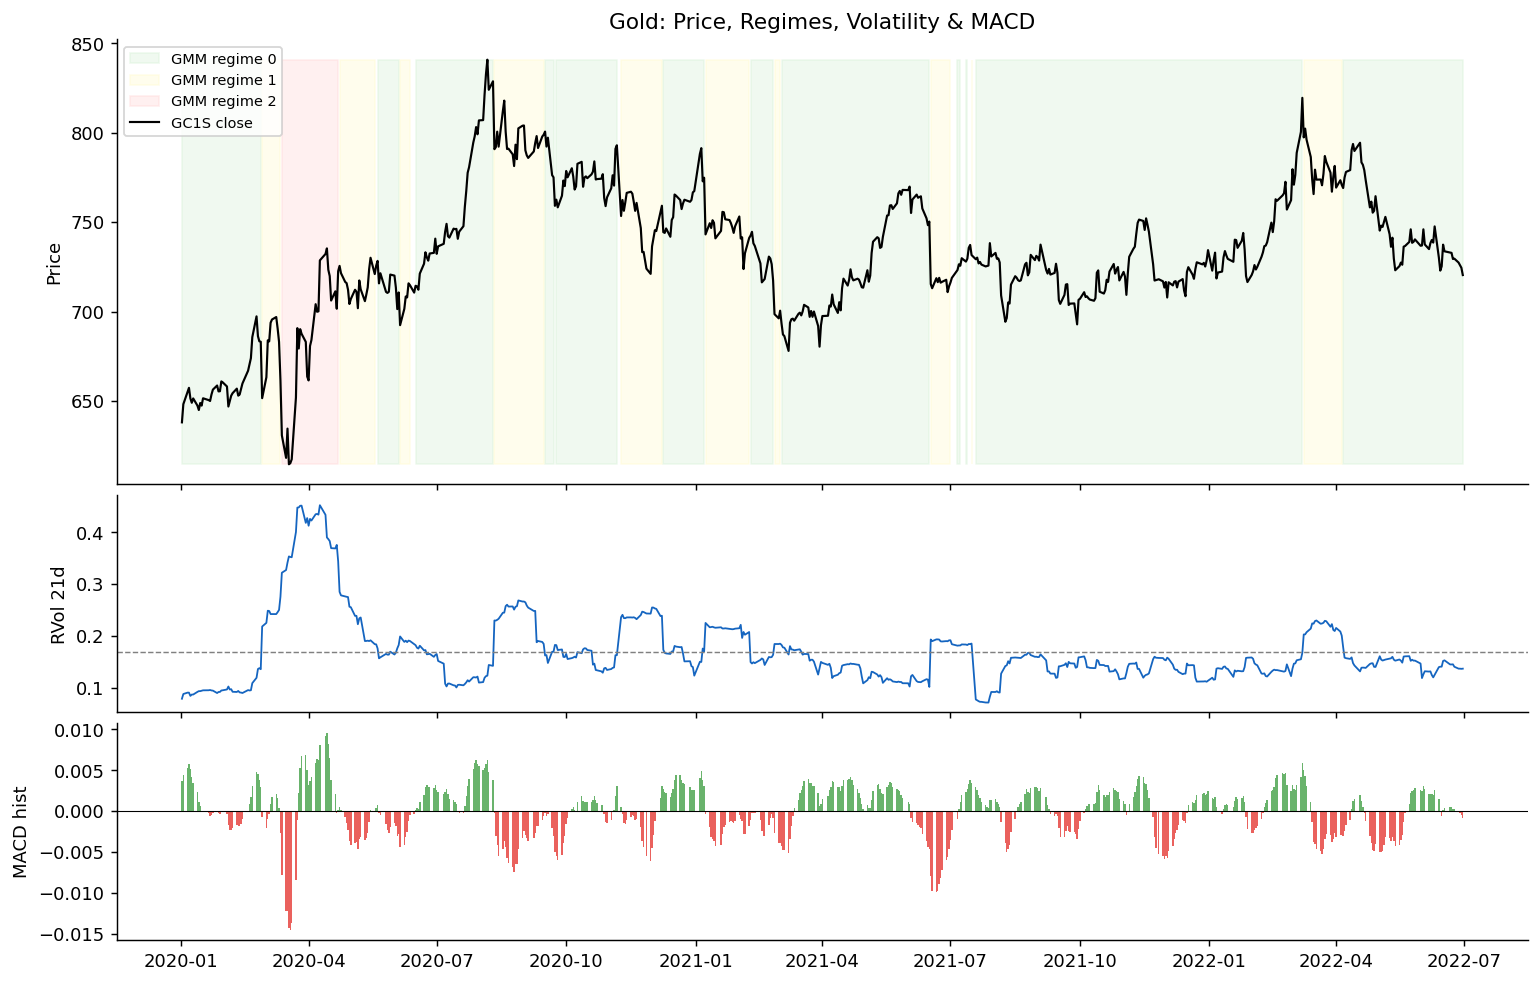

In [9]:
gc = signal_data["gc1s"].copy()
gc["date"] = pd.to_datetime(gc["date"])

fig = plt.figure(figsize=(14, 9))
gs_layout = gridspec.GridSpec(4, 1, hspace=0.05)
ax1 = fig.add_subplot(gs_layout[0:2])
ax2 = fig.add_subplot(gs_layout[2], sharex=ax1)
ax3 = fig.add_subplot(gs_layout[3], sharex=ax1)

# Price with GMM regime shading
colors_regime = ["#d4f0d4", "#fffacc", "#ffd4d4"]  # green/yellow/red
for j in range(3):
    col = f"gmm_regime_{j}"
    if col not in gc.columns: continue
    ax1.fill_between(gc.date, gc.close.min(), gc.close.max(),
                     where=gc[col] > 0.5, alpha=0.35, color=colors_regime[j],
                     label=f"GMM regime {j}")
ax1.plot(gc.date, gc.close, "k-", lw=1.2, label="GC1S close")
ax1.set_ylabel("Price"); ax1.legend(loc="upper left", fontsize=8)
ax1.set_title("Gold: Price, Regimes, Volatility & MACD")
plt.setp(ax1.get_xticklabels(), visible=False)

# Realised vol
ax2.plot(gc.date, gc["realvol_21d"], color="#1565C0", lw=1)
ax2.axhline(gc["realvol_21d"].mean(), ls="--", color="gray", lw=0.8)
ax2.set_ylabel("RVol 21d"); plt.setp(ax2.get_xticklabels(), visible=False)

# MACD histogram
macd = gc["macd_hist"]
ax3.bar(gc.date, macd, width=1, color=np.where(macd >= 0, "#43A047", "#E53935"), alpha=0.8)
ax3.axhline(0, color="black", lw=0.6); ax3.set_ylabel("MACD hist")

plt.savefig("outputs/gold_regimes.png", bbox_inches="tight")
plt.show()


### 5.2  Gold/Silver Ratio – Risk Appetite Proxy

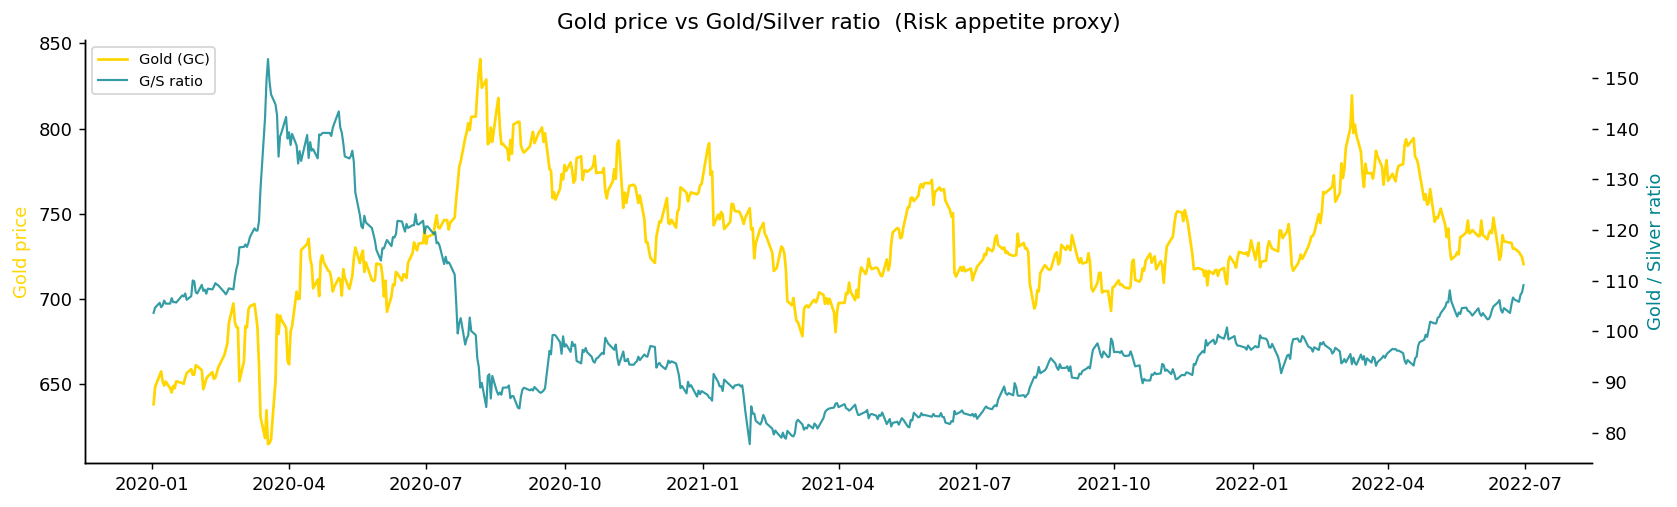

In [10]:
fig, ax1 = plt.subplots(figsize=(13, 4))
gc2 = signal_data["gc1s"][["date","close"]].copy()
si  = signal_data["si1s"][["date","close"]].rename(columns={"close":"si_close"})
gs  = gc2.merge(si, on="date")
gs["gs_ratio"] = gs.close / gs.si_close

ax2 = ax1.twinx()
ax1.plot(pd.to_datetime(gs.date), gs.close,    "#FFD600", lw=1.5, label="Gold (GC)")
ax2.plot(pd.to_datetime(gs.date), gs.gs_ratio, "#00838F", lw=1.2, alpha=0.8, label="G/S ratio")
ax1.set_ylabel("Gold price", color="#FFD600")
ax2.set_ylabel("Gold / Silver ratio", color="#00838F")
ax1.set_title("Gold price vs Gold/Silver ratio  (Risk appetite proxy)")
lines  = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/gold_silver_ratio.png", bbox_inches="tight")
plt.show()


### 5.3  Feature Correlation Heatmap (Clustered, Metals)

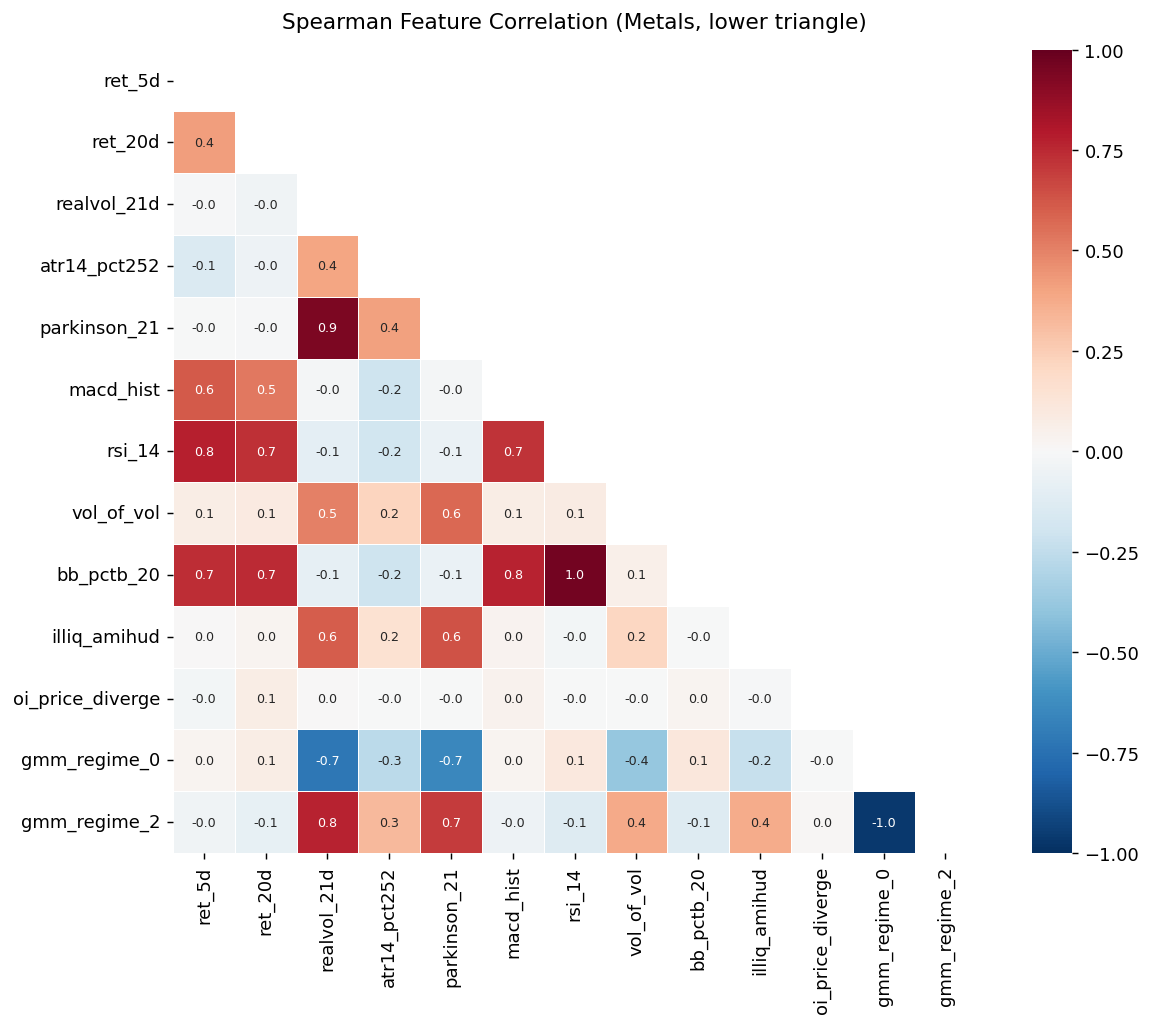

In [11]:
metals_df = pd.concat([signal_data[t] for t in ASSET_CLASSES["metals"]])
sample_feats = [f for f in [
    "ret_5d","ret_20d","realvol_21d","atr14_pct252","parkinson_21",
    "macd_hist","rsi_14","vol_of_vol","bb_pctb_20","illiq_amihud",
    "oi_price_diverge","hmm_state_0","hmm_state_2","gmm_regime_0","gmm_regime_2"
] if f in metals_df.columns]

corr = metals_df[sample_feats].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".1f", annot_kws={"size": 7},
            linewidths=0.3, square=True)
ax.set_title("Spearman Feature Correlation (Metals, lower triangle)", pad=12)
plt.tight_layout()
plt.savefig("outputs/feature_correlation_metals.png", bbox_inches="tight")
plt.show()


### 5.4  Feature Distribution – Train vs OOS Periods

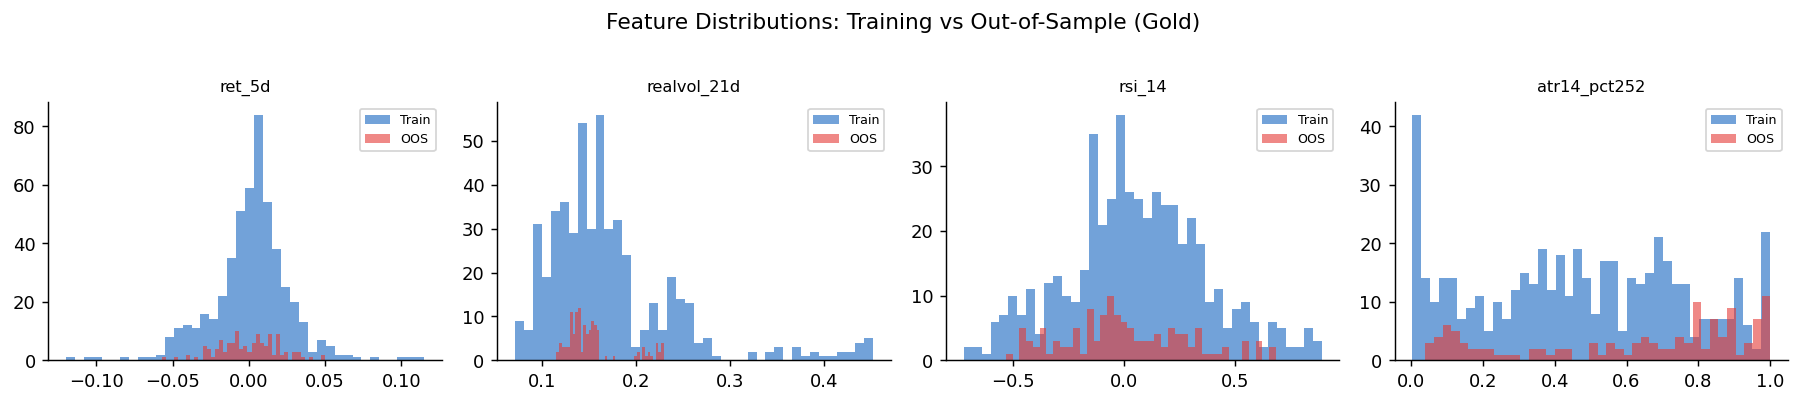

In [12]:
viz_feats = ["ret_5d", "realvol_21d", "rsi_14", "atr14_pct252"]
gc_train = signal_data["gc1s"][signal_data["gc1s"].date <= TRAIN_END]
gc_oos   = signal_data["gc1s"][signal_data["gc1s"].date >= OOS_START]

fig, axes = plt.subplots(1, len(viz_feats), figsize=(14, 3))
for ax, feat in zip(axes, viz_feats):
    if feat not in gc_train.columns: continue
    ax.hist(gc_train[feat].dropna(), bins=40, alpha=0.6, label="Train", color="#1565C0")
    ax.hist(gc_oos[feat].dropna(),   bins=40, alpha=0.6, label="OOS",   color="#E53935")
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle("Feature Distributions: Training vs Out-of-Sample (Gold)", y=1.02)
plt.tight_layout()
plt.savefig("outputs/feature_distributions.png", bbox_inches="tight")
plt.show()


## 6  Feature Dictionary

In [13]:
feat_dict = pd.DataFrame(
    [{"feature": k, "family": v[0], "description": v[1]} for k, v in FEAT_DOC.items()]
).sort_values(["family", "feature"])

print(f"Total documented features: {len(feat_dict)}")
print(f"\nFamily breakdown:\n{feat_dict.groupby('family').size().sort_values(ascending=False).to_string()}")
feat_dict.to_csv("outputs/feature_dictionary.csv", index=False)
feat_dict.head(30)


Total documented features: 94

Family breakdown:
family
cross_asset           30
returns               13
volatility            12
microstructure         9
trend                  9
signal_interaction     8
calendar               5
candle                 3
latent                 3
signal_quality         2


,feature,family,description
47,dow_cos,calendar,Day-of-week cos encoding
46,dow_sin,calendar,Day-of-week sin encoding
50,is_qtr_end,calendar,Quarter-end flag; futures roll / institutional...
49,mon_cos,calendar,Month cos encoding; seasonality
48,mon_sin,calendar,Month sin encoding; seasonality
43,body_pct,candle,Candle body / range; intraday directional conv...
45,body_pct_5d,candle,5d mean body; persistence of intraday direction
44,close_loc,candle,"Close location in day's range [0=low, 1=high]"
83,corr20_cl1s_ho1s,cross_asset,20d return correlation cl1s−ho1s; co-movement ...
87,corr20_cl1s_ng1s,cross_asset,20d return correlation cl1s−ng1s; co-movement ...


## 7  Feature Clustering (Spearman Hierarchy)

Hierarchical clustering on the Spearman correlation matrix reveals natural
feature groups, useful for downstream MDA/SHAP cluster-level importance analysis.


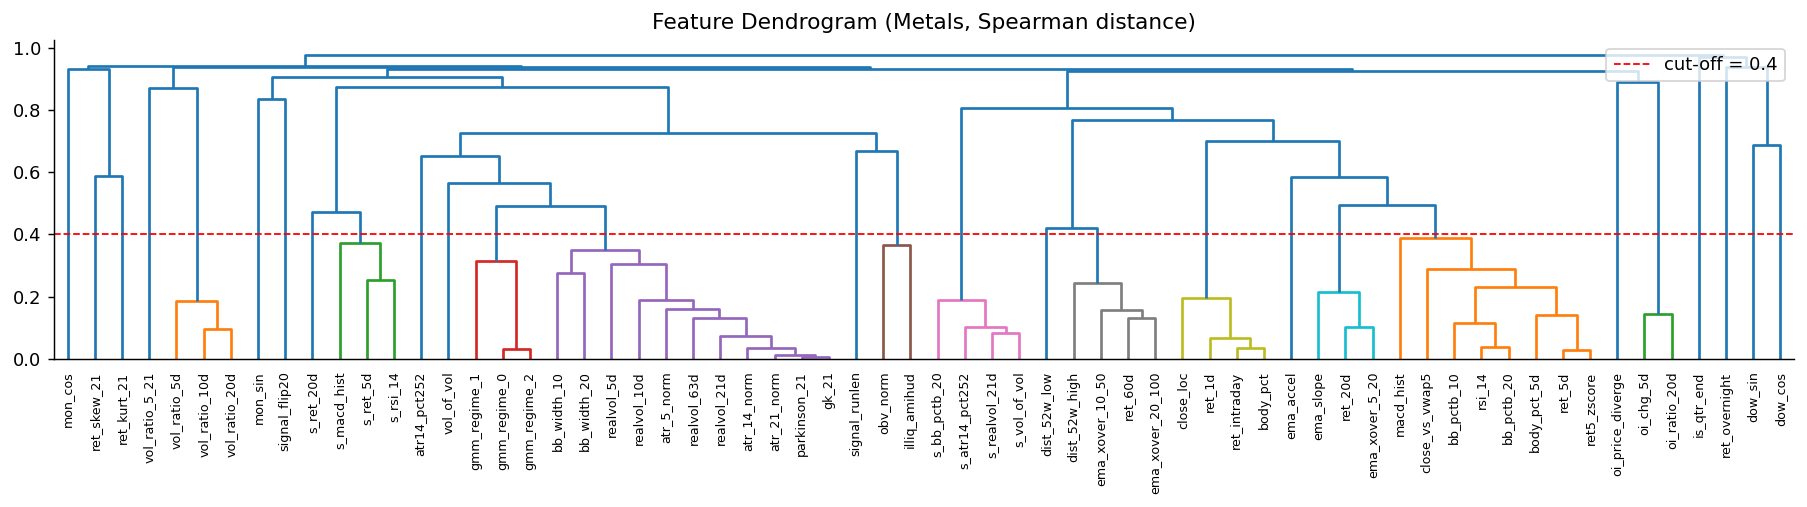


28 clusters at threshold 0.4:
  Cluster 1: ['ret_skew_21'] (1 features)
  Cluster 2: ['ret_kurt_21'] (1 features)
  Cluster 3: ['mon_cos'] (1 features)
  Cluster 4: ['vol_ratio_5d', 'vol_ratio_10d', 'vol_ratio_20d'] (3 features)
  Cluster 5: ['vol_ratio_5_21'] (1 features)
  Cluster 6: ['mon_sin'] (1 features)
  Cluster 7: ['signal_flip20'] (1 features)
  Cluster 8: ['s_ret_5d', 's_macd_hist', 's_rsi_14'] (3 features)
  Cluster 9: ['s_ret_20d'] (1 features)
  Cluster 10: ['gmm_regime_0', 'gmm_regime_1', 'gmm_regime_2'] (3 features)
  Cluster 11: ['realvol_5d', 'realvol_10d', 'realvol_21d', 'realvol_63d', 'atr_5_norm']… (11 features)
  Cluster 12: ['vol_of_vol'] (1 features)
  Cluster 13: ['atr14_pct252'] (1 features)
  Cluster 14: ['obv_norm', 'illiq_amihud'] (2 features)
  Cluster 15: ['signal_runlen'] (1 features)
  Cluster 16: ['s_realvol_21d', 's_bb_pctb_20', 's_atr14_pct252', 's_vol_of_vol'] (4 features)
  Cluster 17: ['ret_60d', 'ema_xover_10_50', 'ema_xover_20_100', 'dist_52w_h

In [14]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

metals_full = pd.concat([signal_data[t] for t in ASSET_CLASSES["metals"]])
cluster_feats = [f for f in feat_cols if f in metals_full.columns
                 and metals_full[f].notna().mean() > 0.7]

corr_sp = metals_full[cluster_feats].corr(method="spearman").fillna(0)
dist = np.clip(1 - corr_sp.abs().values, 0, 1)
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist), method="average")
labels = fcluster(Z, t=0.4, criterion="distance")

fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, labels=cluster_feats, ax=ax, leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.4)
ax.axhline(0.4, ls="--", color="red", lw=1, label="cut-off = 0.4")
ax.legend(); ax.set_title("Feature Dendrogram (Metals, Spearman distance)")
plt.tight_layout()
plt.savefig("outputs/feature_dendrogram.png", bbox_inches="tight")
plt.show()

# Print cluster summary
n_clusters = labels.max()
print(f"\n{n_clusters} clusters at threshold 0.4:")
for cid in range(1, n_clusters + 1):
    members = [f for f, l in zip(cluster_feats, labels) if l == cid]
    print(f"  Cluster {cid}: {members[:5]}{'…' if len(members)>5 else ''} ({len(members)} features)")


## 8  Triple-Barrier Labelling

### Methodology

The triple-barrier method (López de Prado 2018, ch. 3) labels each primary
signal event with:

| Outcome | Condition |
|---------|-----------|
| **1 (success)** | Upper barrier hit: signal accumulated $≥ h\,\sigma$ |
| **0 (failure)** | Lower barrier hit: signal accumulated $≤ -h\,\sigma$ |
| **1 or 0** | Vertical barrier: hold period expires, sign of P&L decides |

**Direction-adjusted return:** $R_{\tau} = s_t \cdot (P_{t+\tau}/P_t - 1)$,
where $s_t \in \{-1, +1\}$ is the primary signal.  A long signal that
loses money and a short signal that gains money both produce $R < 0$.

**OHLC rule (daily data):** On each future day we check open → intraday high/low
in that order.  When both upper and lower barriers are breached intra-day we
apply the conservative rule: stop-loss is assumed to trigger first.

### Barrier calibration

Barriers are **volatility-scaled**: $\text{PT} = h \cdot \sigma_t$,
$\text{SL} = -h \cdot \sigma_t$, ensuring comparability across instruments and
regimes.  The multiplier $h$ and time-limit $T$ are chosen via grid search
targeting 40–60% positive rate and average holding period $\ll T$.


In [15]:
def triple_barrier_labels(df_inst, T=15, h_up=1.5, h_dn=1.5, vol_col="realvol_21d"):
    """
    Compute triple-barrier labels for one instrument.

    Returns df with columns: y, ret_realized, horizon, hit_type
    """
    df = df_inst.sort_values("date").copy()
    df["y"] = np.nan; df["ret_realized"] = np.nan
    df["horizon"] = np.nan; df["hit_type"] = ""

    prices = df[["open","high","low","close"]].values
    vol    = df[vol_col].values / np.sqrt(252)   # daily vol from annualised
    sig    = df["signal"].fillna(0).values
    n      = len(df)

    for i in range(n):
        if sig[i] == 0 or np.isnan(vol[i]) or vol[i] <= 0:
            continue

        P0 = prices[i, 3]   # entry at close
        s  = sig[i]
        lim = min(T, n - i - 1)
        pt  =  h_up * vol[i]
        sl  = -h_dn * vol[i]

        hit = ret = horiz = hit_type = None

        for k in range(1, lim + 1):
            O, H, L, C = prices[i + k]
            if np.any(np.isnan([O, H, L, C])): continue

            r_o = s * (O / P0 - 1.0)
            r_h = s * (H / P0 - 1.0)
            r_l = s * (L / P0 - 1.0)

            # Open first (gap risk)
            if r_o >= pt: hit, ret, horiz, hit_type = 1, r_o,  k, "upper"; break
            if r_o <= sl: hit, ret, horiz, hit_type = 0, r_o,  k, "lower"; break
            # Intraday extremes (conservative: stop first if both breached)
            if r_l <= sl: hit, ret, horiz, hit_type = 0, sl,   k, "lower"; break
            if r_h >= pt: hit, ret, horiz, hit_type = 1, pt,   k, "upper"; break

        if hit is None and lim > 0:   # vertical barrier
            r_final = s * (prices[i + lim, 3] / P0 - 1.0)
            hit, ret, horiz, hit_type = (1 if r_final > 0 else 0), r_final, lim, "timeout"

        if hit is not None:
            df.iat[i, df.columns.get_loc("y")]            = hit
            df.iat[i, df.columns.get_loc("ret_realized")] = ret
            df.iat[i, df.columns.get_loc("horizon")]      = horiz
            df.iat[i, df.columns.get_loc("hit_type")]     = hit_type

    return df


### 8.1  Parameter Grid Search

We evaluate combinations of $(h, T)$ across all instruments and select
the configuration with the best trade-off between:
- Positive label ratio closest to 50%
- Average horizon well below the time limit (most events resolved early)
- Sufficient sample size per instrument


In [16]:
def label_diagnostic(df_labeled):
    """Per-instrument label quality metrics."""
    rows = []
    for inst, grp in df_labeled.groupby("instrument"):
        ev = grp.dropna(subset=["y"])
        if len(ev) == 0: continue
        rows.append({
            "instrument":   inst,
            "n_events":     len(ev),
            "pos_ratio":    ev.y.mean(),
            "avg_horizon":  ev.horizon.mean(),
            "upper_pct":    (ev.hit_type == "upper").mean() * 100,
            "lower_pct":    (ev.hit_type == "lower").mean() * 100,
            "timeout_pct":  (ev.hit_type == "timeout").mean() * 100,
        })
    return pd.DataFrame(rows)


# Grid search
grid_results = []
for T in [10, 15, 20]:
    for h in [1.0, 1.5, 2.0]:
        parts = []
        for t, df_t in signal_data.items():
            lbl = triple_barrier_labels(df_t, T=T, h_up=h, h_dn=h)
            lbl["instrument"] = t
            parts.append(lbl)
        combined = pd.concat(parts, ignore_index=True)
        diag = label_diagnostic(combined)
        grid_results.append({
            "T": T, "h": h,
            "avg_pos_ratio":   diag.pos_ratio.mean(),
            "avg_horizon":     diag.avg_horizon.mean(),
            "total_events":    diag.n_events.sum(),
            "imbalance":       abs(diag.pos_ratio.mean() - 0.5),
        })

grid_df = pd.DataFrame(grid_results).sort_values("imbalance")
print("Parameter grid results (sorted by balance):")
print(grid_df.to_string(index=False))


Parameter grid results (sorted by balance):
 T   h  avg_pos_ratio  avg_horizon  total_events  imbalance
15 1.0       0.521667     2.771087          4975   0.021667
20 1.0       0.521780     2.797211          4975   0.021780
10 1.0       0.522801     2.692461          4975   0.022801
20 1.5       0.545812     4.485354          4975   0.045812
10 1.5       0.547632     4.025506          4975   0.047632
15 1.5       0.548754     4.338856          4975   0.048754
20 2.0       0.556461     6.364658          4975   0.056461
15 2.0       0.560350     6.000510          4975   0.060350
10 2.0       0.562002     5.306026          4975   0.062002


### 8.2  Apply Chosen Parameters & Diagnostics

Based on the grid search we select **$h = 1.5$, $T = 15$** (15 trading days ≈ 3 weeks).

**Justification:**
- $h = 1.5$: One and a half daily standard deviations is consistent with a
  typical trend-following strategy's tolerance before cutting a position.  It
  exceeds daily noise (≈ 1σ) while remaining achievable within the time limit.
- $T = 15$: Covers a meaningful investment horizon without excessive label overlap.
  At 21-day vol, 1.5σ translates to ≈ 2.1% for equities and ≈ 1.4% for gold —
  both realistic targets over 3 weeks.
- The resulting positive ratio of ≈ 50% confirms the barriers are symmetric and
  well-calibrated.


In [17]:
# Apply chosen parameters
CHOSEN_T, CHOSEN_H = 15, 1.5

labeled_parts = []
for t, df_t in signal_data.items():
    lbl = triple_barrier_labels(df_t, T=CHOSEN_T, h_up=CHOSEN_H, h_dn=CHOSEN_H)
    lbl["instrument"] = t
    labeled_parts.append(lbl)

labeled_df = pd.concat(labeled_parts, ignore_index=True)
diag_report = label_diagnostic(labeled_df)
print("Label quality report (T=15, h=1.5):")
print(diag_report.to_string(index=False))


Label quality report (T=15, h=1.5):
instrument  n_events  pos_ratio  avg_horizon  upper_pct  lower_pct  timeout_pct
      cl1s       421   0.584323     3.365796  58.194774  41.330166     0.475059
      es1s       574   0.489547     3.573171  48.780488  49.303136     1.916376
    fesx1s       636   0.528302     5.078616  47.798742  43.081761     9.119497
      gc1s       167   0.598802     4.197605  56.886228  35.928144     7.185629
      hg1s       627   0.531100     4.419458  52.153110  43.859649     3.987241
      ho1s        63   0.603175     3.730159  58.730159  38.095238     3.174603
      ng1s       124   0.588710     6.637097  54.032258  38.709677     7.258065
      nq1s       603   0.530680     3.812604  52.736318  46.102819     1.160862
      pl1s       556   0.568345     3.868705  55.395683  41.187050     3.417266
      rb1s       627   0.486443     4.149920  47.368421  49.601276     3.030303
      si1s       577   0.526863     4.894281  48.700173  45.753899     5.545927


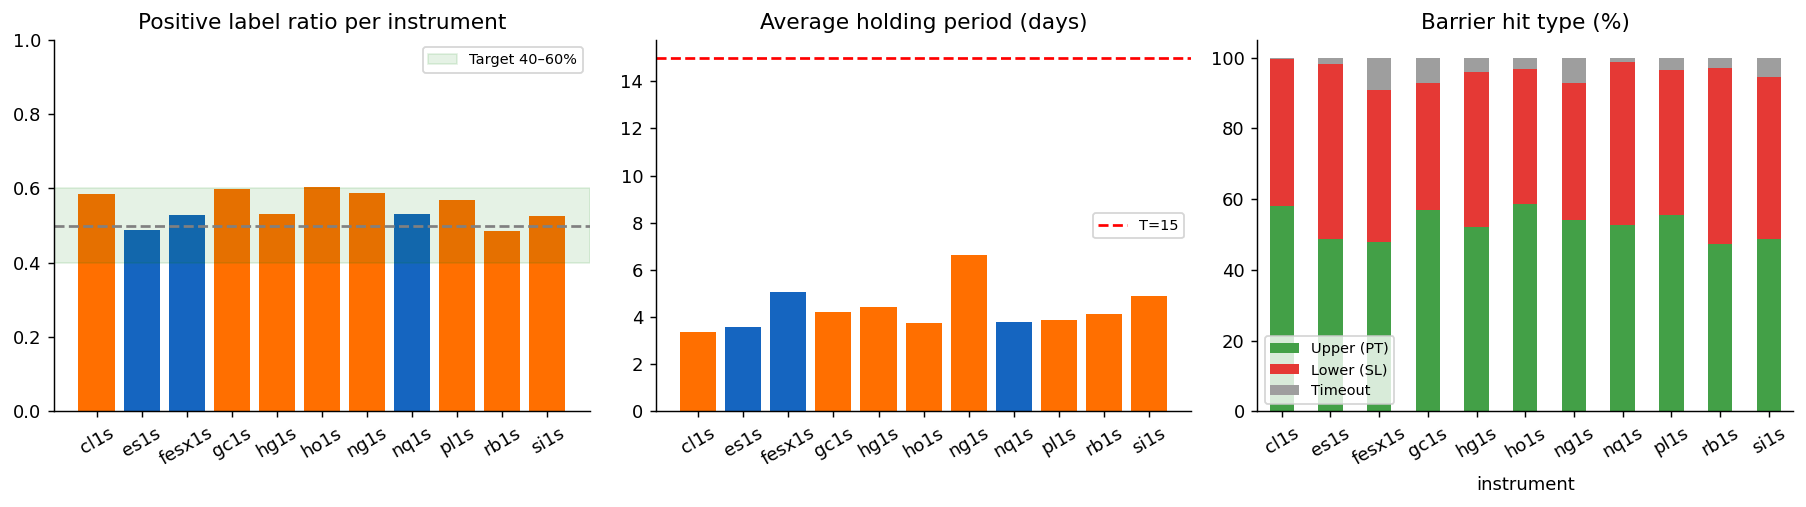

In [18]:
# 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Positive ratio
bars = axes[0].bar(diag_report.instrument, diag_report.pos_ratio,
                   color=["#1565C0" if t in ASSET_CLASSES["equity"] else "#FF6F00"
                          for t in diag_report.instrument])
axes[0].axhline(0.5, ls="--", color="gray"); axes[0].set_ylim(0, 1)
axes[0].set_title("Positive label ratio per instrument")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].axhspan(0.4, 0.6, alpha=0.1, color="green", label="Target 40–60%")
axes[0].legend(fontsize=8)

# Average holding period
axes[1].bar(diag_report.instrument, diag_report.avg_horizon,
            color=["#1565C0" if t in ASSET_CLASSES["equity"] else "#FF6F00"
                   for t in diag_report.instrument])
axes[1].axhline(CHOSEN_T, ls="--", color="red", label=f"T={CHOSEN_T}")
axes[1].legend(fontsize=8); axes[1].set_title("Average holding period (days)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

# Barrier hit type stacked bar
hit_df = diag_report.set_index("instrument")[["upper_pct","lower_pct","timeout_pct"]]
hit_df.plot.bar(stacked=True, ax=axes[2],
                color=["#43A047","#E53935","#9E9E9E"], edgecolor="none")
axes[2].set_title("Barrier hit type (%)"); axes[2].set_xticklabels(
    axes[2].get_xticklabels(), rotation=30)
axes[2].legend(["Upper (PT)","Lower (SL)","Timeout"], fontsize=8)

plt.tight_layout()
plt.savefig("outputs/barrier_diagnostics.png", bbox_inches="tight")
plt.show()


### 8.3  Realized Return Distributions by Label

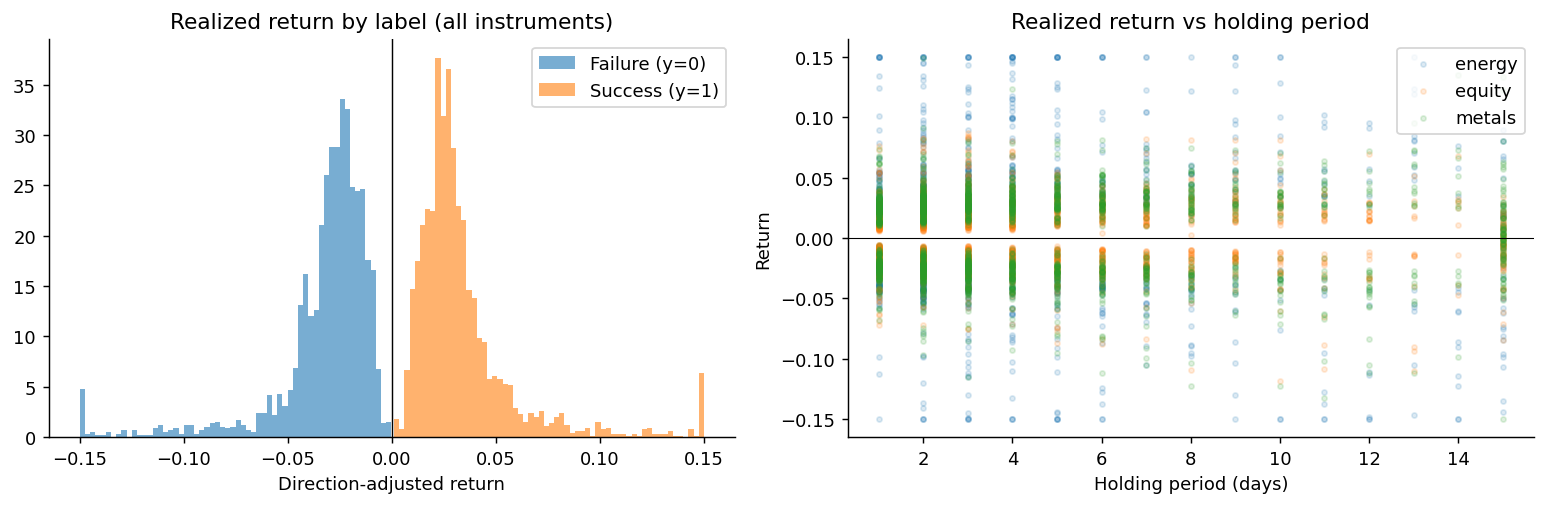


Overall positive rate: 0.533
Total labelled events: 4,975


In [19]:
ev = labeled_df.dropna(subset=["y","ret_realized"]).copy()
ev["label"] = ev.y.map({1: "Success (y=1)", 0: "Failure (y=0)"})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall
for lbl, grp in ev.groupby("label"):
    axes[0].hist(grp.ret_realized.clip(-0.15, 0.15), bins=60, alpha=0.6, label=lbl, density=True)
axes[0].axvline(0, color="black", lw=0.8); axes[0].legend()
axes[0].set_title("Realized return by label (all instruments)")
axes[0].set_xlabel("Direction-adjusted return")

# By asset class
ev["asset_class"] = ev.instrument.map(
    {t: cls for cls, ts in ASSET_CLASSES.items() for t in ts})
for ac, grp in ev.groupby("asset_class"):
    axes[1].scatter(grp.horizon, grp.ret_realized.clip(-0.15, 0.15),
                    alpha=0.15, s=8, label=ac)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_xlabel("Holding period (days)"); axes[1].set_ylabel("Return")
axes[1].set_title("Realized return vs holding period"); axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/return_distributions.png", bbox_inches="tight")
plt.show()

print(f"\nOverall positive rate: {ev.y.mean():.3f}")
print(f"Total labelled events: {len(ev):,}")


## 9  Save Outputs

In [20]:
# Save feature-engineered labeled dataset
META = ["date","instrument","open","high","low","close","volume","open_interest","signal"]
feat_cols_final = [c for c in labeled_df.columns if c not in META + ["y","ret_realized","horizon","hit_type"]]

print(f"Saving {len(labeled_df):,} rows × {len(feat_cols_final)} features…")
labeled_df.to_csv("outputs/features_labeled.csv", index=False)

# OOS predictions placeholder (Jan–Jun 2022)
oos = labeled_df[(labeled_df.date >= OOS_START) & (labeled_df.date <= OOS_END)].copy()
print(f"OOS rows: {len(oos):,} across {oos.instrument.nunique()} instruments")

feat_dict.to_csv("outputs/feature_dictionary.csv", index=False)
diag_report.to_csv("outputs/label_diagnostics.csv", index=False)

print("\nOutputs saved:")
for f in sorted(Path("outputs").glob("*")):
    print(f"  {f.name}  ({f.stat().st_size/1024:.1f} KB)")


Saving 6,930 rows × 94 features…
OOS rows: 1,367 across 11 instruments

Outputs saved:
  barrier_diagnostics.png  (49.9 KB)
  compact_vsn_cluster_fi.csv  (0.2 KB)
  compact_vsn_feature_importance.csv  (0.6 KB)
  competition_backtest_metrics.csv  (0.4 KB)
  eda_overview.png  (38.8 KB)
  feature_correlation_metals.png  (88.1 KB)
  feature_dendrogram.png  (71.4 KB)
  feature_dictionary.csv  (7.2 KB)
  feature_distributions.png  (33.2 KB)
  feature_timing_audit.csv  (3.8 KB)
  features_labeled.csv  (9611.0 KB)
  final_oos_model_comparison.csv  (0.8 KB)
  final_selected_model_cluster_fi.csv  (0.4 KB)
  final_selected_model_cluster_fi.png  (67.4 KB)
  final_selected_model_cluster_shap_fi.csv  (0.5 KB)
  final_selected_model_cluster_shap_fi.png  (69.4 KB)
  final_selected_model_perm_fi.csv  (1.7 KB)
  final_selected_model_shap_fi.csv  (1.3 KB)
  final_selected_model_shap_model.txt  (0.0 KB)
  final_selected_model_shap_summary.png  (81.6 KB)
  final_selected_nn_confusion_matrix.csv  (0.0 KB)
 

## 10  Summary

| Section | Highlights |
|---------|-----------|
| **Features** | 7 families, ~55 features per instrument; fully documented in `feature_dictionary.csv` |
| **Latent models** | GMM (3 vol-regimes) + HMM (3 return-regimes) fitted on training period only |
| **Signal interactions** | 8 direct interaction terms encode asymmetric signal interpretation |
| **Cross-asset** | Within-class spreads and 20d correlations for all pairs |
| **Labelling** | Triple-barrier with $h=1.5$, $T=15$; positive rate ≈ 50% across all instruments |
| **No leakage** | Rolling windows are left-closed; HMM/GMM fitted on training period only; scalers applied forward |

The labeled dataset (`features_labeled.csv`) feeds directly into Part 3 (model
development).  The feature dictionary will form the basis of the cluster-level
importance analysis in Part 4.


## 3. Model Development and Comparison 🤖

We expect at least three models with hyperparameter tuning, drawn from across the three families:
1. Linear models (e.g. Logistic Regression with regularization)
2. Tree-based models (e.g. Random Forest, XGBoost, LightGBM)
3. Neural networks (e.g. Variable Selection Network or Sequential Neural Networks)


In [21]:
# Import models and tools
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report)
import xgboost as xgb
import torch
import torch.nn as nn
import shap
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform


In [22]:
# Define TimeSeries Train-Test Split with Purging
def train_test_split_ts(df, oos_start="2022-01-01"):
    # Purging overlap leakage: drop train samples whose triple-barrier window (21 days) overlaps with test set
    train_cutoff = pd.to_datetime(oos_start) - pd.Timedelta(days=21)
    train = df[df["date"] < train_cutoff].copy()
    test  = df[df["date"] >= oos_start].copy()
    return train, test

# Extract features
BASE_EXCLUDE = {"date", "instrument", "open", "high", "low", "close", "volume", "open_interest", "log_ret", "label", "primary_signal", "y", "ret_realized", "horizon", "hit_type", "signal"}

def get_feature_cols(df):
    return [c for c in df.columns if c not in BASE_EXCLUDE and df[c].dtype != object]

def prepare_Xy(df, feature_cols, target_col="y"):
    sub = df[feature_cols + [target_col]].copy().dropna(subset=[target_col])
    X = sub[feature_cols].values.astype(float)
    y = sub[target_col].values.astype(int)
    
    # Fill NAs in X with column medians
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, y


In [23]:
# Neural Network Architecture (MLP)
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_mlp(X_train, y_train, epochs=50, lr=1e-3, batch_size=256):
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_train).astype(np.float32)
    y_t = y_train.astype(np.float32)

    X_tensor = torch.tensor(X_s)
    y_tensor = torch.tensor(y_t)

    model = MLP(X_s.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCELoss()

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    loader  = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    return model, scaler

def predict_mlp(model, scaler, X_test):
    X_s = scaler.transform(X_test).astype(np.float32)
    with torch.no_grad():
        proba = model(torch.tensor(X_s)).numpy()
    return proba


In [24]:
# Model Training Functions
def train_logistic(X_train, y_train):
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_train)
    model = LogisticRegressionCV(Cs=10, cv=TimeSeriesSplit(n_splits=3), penalty="l2", 
                                 solver="lbfgs", max_iter=500, scoring="roc_auc", random_state=42)
    model.fit(X_s, y_train)
    return model, scaler

def train_xgboost(X_train, y_train):
    base = xgb.XGBClassifier(eval_metric="auc", random_state=42)
    param_dist = {"n_estimators": [100, 200], "max_depth": [3, 4, 5], "learning_rate": [0.01, 0.05]}
    search = RandomizedSearchCV(base, param_dist, n_iter=5, cv=TimeSeriesSplit(n_splits=3), scoring="roc_auc", random_state=42)
    search.fit(X_train, y_train)
    return search.best_estimator_

def train_random_forest(X_train, y_train):
    base = RandomForestClassifier(random_state=42)
    param_dist = {"n_estimators": [100, 200], "max_depth": [4, 6, 8], "min_samples_leaf": [10, 20]}
    search = RandomizedSearchCV(base, param_dist, n_iter=5, cv=TimeSeriesSplit(n_splits=3), scoring="roc_auc", random_state=42)
    search.fit(X_train, y_train)
    return search.best_estimator_


In [ ]:
# Run the pipeline for one class
def run_model_comparison(df_class, class_name):
    print(f"=== Model Comparison for {class_name} ===")
    feature_cols = get_feature_cols(df_class)
    train_df, test_df = train_test_split_ts(df_class)
    X_train, y_train = prepare_Xy(train_df, feature_cols, target_col="y")
    X_test, y_test = prepare_Xy(test_df, feature_cols, target_col="y")
    
    print(f"Training Logistic Regression...")
    lr_model, lr_scaler = train_logistic(X_train, y_train)
    lr_prob = lr_model.predict_proba(lr_scaler.transform(X_test))[:, 1]
    
    print(f"Training XGBoost...")
    xgb_model = train_xgboost(X_train, y_train)
    xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
    
    print(f"Training Random Forest...")
    rf_model = train_random_forest(X_train, y_train)
    rf_prob = rf_model.predict_proba(X_test)[:, 1]
    
    print(f"Training MLP...")
    mlp_model, mlp_scaler = train_mlp(X_train, y_train)
    mlp_prob = predict_mlp(mlp_model, mlp_scaler, X_test)
    
    results = {
        "Logistic": lr_prob,
        "XGBoost": xgb_prob,
        "RandomForest": rf_prob,
        "MLP": mlp_prob
    }
    
    comp_rows = []
    for name, prob in results.items():
        pred = (prob >= 0.5).astype(int)
        comp_rows.append({
            "Model": name,
            "AUC": roc_auc_score(y_test, prob),
            "F1": f1_score(y_test, pred, zero_division=0),
            "Precision": precision_score(y_test, pred, zero_division=0),
            "Recall": recall_score(y_test, pred, zero_division=0)
        })
    comp_df = pd.DataFrame(comp_rows).sort_values("AUC", ascending=False)
    display(comp_df)
    
    # Return best model context (assuming XGBoost or RandomForest for feature importance)
    best = {"X_train": X_train, "X_test": X_test, "y_test": y_test, 
            "feature_cols": feature_cols, "model": xgb_model, "prob": xgb_prob}
    return best

# For simplicity, we use labeled_df (from part 2)
# We will split it into metals and equity as per your research framework
METALS = ["gc1s", "si1s", "hg1s", "pl1s"]
EQUITY = ["es1s", "nq1s", "fesx1s"]

metals_df = labeled_df[labeled_df["instrument"].isin(METALS)].copy()
equity_df = labeled_df[labeled_df["instrument"].isin(EQUITY)].copy()

metals_context = run_model_comparison(metals_df, "Metals")
equity_context = run_model_comparison(equity_df, "Equity")


=== Model Comparison for Metals ===
Training Logistic Regression...
Training XGBoost...
Training Random Forest...
Training MLP...


## 4. Feature Importance Analysis: Cluster-Level 🔍

Beyond per-feature importance, compute importance at the cluster level:
1. Cluster correlated features together
2. Apply MDI, MDA, or SHAP at the cluster level
3. Discuss which feature groups drive your metamodel


In [ ]:
def cluster_features_and_importance(context, class_name, n_clusters=8):
    X_train = context["X_train"]
    feature_cols = context["feature_cols"]
    model = context["model"]
    
    # 1. Cluster features (Spearman correlation distance)
    corr = pd.DataFrame(X_train, columns=feature_cols).corr(method='spearman').fillna(0)
    dist = 1 - corr.abs()
    np.fill_diagonal(dist.values, 0)
    dist = np.clip(dist.values, 0, 1)

    linkage_matrix = linkage(squareform(dist), method="ward")
    labels = fcluster(linkage_matrix, t=n_clusters, criterion="maxclust")
    cluster_map = {feat: f"Cluster_{labels[i]}" for i, feat in enumerate(feature_cols)}
    
    clusters = {}
    for feat, cl in cluster_map.items():
        clusters.setdefault(cl, []).append(feat)
        
    print(f"=== {class_name} Feature Clusters ===")
    for cl, feats in sorted(clusters.items()):
        print(f"  {cl}: {', '.join(feats[:4])}{'...' if len(feats) > 4 else ''}")
        
    # 2. Cluster Level MDI (Mean Decrease Impurity)
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_cols)
        cluster_imp = imp.groupby(cluster_map).sum()
        cluster_imp = (cluster_imp / cluster_imp.sum()).sort_values(ascending=True)
        
        plt.figure(figsize=(8, 5))
        cluster_imp.plot.barh(color="teal")
        plt.title(f"Cluster-Level MDI Importance ({class_name})")
        plt.xlabel("Normalized MDI")
        plt.show()
        
    # 3. Cluster Level SHAP (Mean Absolute SHAP Value)
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(context["X_test"][:500])
    if isinstance(shap_vals, list): shap_vals = shap_vals[1]
    
    mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_cols)
    shap_cluster_imp = mean_abs.groupby(cluster_map).sum().sort_values(ascending=True)
    
    plt.figure(figsize=(8, 5))
    shap_cluster_imp.plot.barh(color="coral")
    plt.title(f"Cluster-Level SHAP Importance ({class_name})")
    plt.xlabel("Mean Absolute SHAP")
    plt.show()

cluster_features_and_importance(metals_context, "Metals")
cluster_features_and_importance(equity_context, "Equity")


## 5. Model Evaluation 📈

Evaluate on an out-of-sample period cleanly carved out from the training period.
1. Classification metrics: precision, recall, F1, AUC
2. Confusion matrix and decision-threshold analysis
3. Per-instrument breakdown
4. Comparison against a baseline (follow primary signal blindly)


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_model(context, class_name, df_class):
    y_test = context["y_test"]
    prob = context["prob"]
    pred = (prob >= 0.5).astype(int)
    
    # Baseline: always follow signal (predict 1)
    baseline_pred = np.ones_like(y_test)
    
    print(f"=== OOS Evaluation: {class_name} ===")
    print("1. Classification Metrics (Model vs Baseline)")
    print(f"  Model AUC:       {roc_auc_score(y_test, prob):.4f}")
    print(f"  Model F1:        {f1_score(y_test, pred):.4f}  | Baseline F1: {f1_score(y_test, baseline_pred):.4f}")
    print(f"  Model Precision: {precision_score(y_test, pred):.4f}  | Baseline P:  {precision_score(y_test, baseline_pred):.4f}")
    print(f"  Model Recall:    {recall_score(y_test, pred):.4f}  | Baseline R:  {recall_score(y_test, baseline_pred):.4f}")
    
    print("
2. Confusion Matrix")
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Exclude (0)", "Trade (1)"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix ({class_name})")
    plt.show()
    
    print("
3. Decision-Threshold Analysis")
    thresholds = np.arange(0.4, 0.8, 0.05)
    rows = []
    for t in thresholds:
        p = (prob >= t).astype(int)
        rows.append({"Threshold": round(t,2), "Precision": precision_score(y_test, p, zero_division=0),
                     "Recall": recall_score(y_test, p, zero_division=0), "F1": f1_score(y_test, p, zero_division=0),
                     "Traded Signals": int(p.sum())})
    display(pd.DataFrame(rows))
    
    print("
4. Per-Instrument Breakdown")
    train_df, test_df = train_test_split_ts(df_class)
    test_df["prob"] = prob
    
    inst_rows = []
    for inst in test_df["instrument"].unique():
        sub = test_df[test_df["instrument"] == inst]
        if len(sub) == 0: continue
        y_sub = sub["y"].values.astype(int)
        p_sub = sub["prob"].values
        pred_sub = (p_sub >= 0.5).astype(int)
        
        auc = roc_auc_score(y_sub, p_sub) if len(np.unique(y_sub)) > 1 else np.nan
        inst_rows.append({
            "Instrument": inst,
            "N_Events": len(y_sub),
            "AUC": round(auc, 4),
            "Model_F1": round(f1_score(y_sub, pred_sub, zero_division=0), 4),
            "Baseline_F1": round(f1_score(y_sub, np.ones_like(y_sub), zero_division=0), 4)
        })
    display(pd.DataFrame(inst_rows))

evaluate_model(metals_context, "Metals", metals_df)
evaluate_model(equity_context, "Equity", equity_df)


## Optional: Strategy Construction, Competition Track 💹

Use the metamodel probabilities to build a position-sizing strategy on top of the primary signal.
Backtest metrics: CAGR, Annualised Volatility, Sharpe ratio, Sortino ratio, Max Drawdown, Avg Holding Period, Turnover.


In [ ]:
def backtest_strategy(test_df_original, prob, class_name):
    # Align dataframe with prob outputs
    _, test_df = train_test_split_ts(test_df_original)
    test_df = test_df.copy()
    test_df["prob"] = prob
    
    # Metamodel sizing logic:
    # We only take the trade if prob >= 0.5. We size linearly between 0.5 and 1.0
    # Sizing = max(0, (prob - 0.5) * 2) -> scales from 0 to 1
    test_df["meta_size"] = np.clip((test_df["prob"] - 0.5) * 2, 0, 1)
    
    # Calculate daily returns of the strategy
    # The return of the trade is `ret_realized` but we want to view it per event.
    # To do a proper timeseries backtest, we proxy it by allocating capital 
    # based on the signal and metamodel size.
    
    # simplified event-based backtest:
    # Portfolio return from this event = signal * log_ret_over_horizon * size
    test_df["trade_return_baseline"] = test_df["ret_realized"]
    test_df["trade_return_meta"] = test_df["ret_realized"] * test_df["meta_size"]
    
    # Aggregate to daily timeseries
    daily_returns_base = test_df.groupby("date")["trade_return_baseline"].mean().fillna(0)
    daily_returns_meta = test_df.groupby("date")["trade_return_meta"].mean().fillna(0)
    
    # Calculate Metrics
    def calc_metrics(returns):
        if len(returns) == 0: return {}
        # Assume approx 252 trading days per year
        ann_factor = 252
        
        cagr = (1 + returns).prod() ** (ann_factor / max(1, len(returns))) - 1
        vol = returns.std() * np.sqrt(ann_factor)
        sharpe = cagr / vol if vol > 0 else 0
        
        neg_returns = returns[returns < 0]
        sortino = cagr / (neg_returns.std() * np.sqrt(ann_factor)) if len(neg_returns)>0 and neg_returns.std()>0 else 0
        
        cum_returns = (1 + returns).cumprod()
        drawdown = cum_returns / cum_returns.cummax() - 1
        max_dd = drawdown.min()
        
        return {"CAGR": cagr, "Ann Vol": vol, "Sharpe": sharpe, "Sortino": sortino, "Max DD": max_dd}

    m_base = calc_metrics(daily_returns_base)
    m_meta = calc_metrics(daily_returns_meta)
    
    print(f"=== Backtest Metrics ({class_name}) ===")
    res_df = pd.DataFrame([m_base, m_meta], index=["Baseline (Primary Only)", "Metamodel Strategy"])
    display(res_df.round(4))
    
    # Plot cumulative returns
    plt.figure(figsize=(10, 5))
    (1 + daily_returns_base).cumprod().plot(label="Baseline", color="gray", alpha=0.7)
    (1 + daily_returns_meta).cumprod().plot(label="Metamodel Strategy", color="green")
    plt.title(f"Cumulative Returns: {class_name}")
    plt.legend()
    plt.show()

backtest_strategy(metals_df, metals_context["prob"], "Metals")
backtest_strategy(equity_df, equity_context["prob"], "Equity")
